In [12]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import joblib
from lime.lime_tabular import LimeTabularExplainer
import warnings
import shap
warnings.filterwarnings('ignore')

In [2]:
# Data
dataset = pd.read_csv('./data/empid_test_set.csv')

feature = dataset.drop(columns=['Attrition'])  
labels = dataset['Attrition']


print(feature.shape)
labels.head()

(336, 35)


0    0
1    1
2    0
3    1
4    0
Name: Attrition, dtype: int64

Global Interpretations (Categorized By JobRole) function

In [3]:
def explainn(model, X_test, feature_names=None, class_names=None, 
                                 group_col='JobRole', num_samples=1000, 
                                 num_features=10, random_state=42):
    if isinstance(X_test, np.ndarray):
        X_test = pd.DataFrame(X_test, columns=feature_names)
    
    feature_cols = [c for c in X_test.columns if c != group_col]
    X_features = X_test[feature_cols].values
    
    explainer = LimeTabularExplainer(
        X_features,
        feature_names=feature_cols,
        class_names=class_names,
        discretize_continuous=True,
        random_state=random_state
    )
    
    groups = X_test.groupby(group_col)
    group_explanations = {}
    
    for group_val, group_df in groups:
        group_features = group_df[feature_cols].values
        all_explanations = []
        
        for idx in range(len(group_features)):
            instance = group_features[idx]
            exp = explainer.explain_instance(
                instance, 
                model.predict_proba,
                num_samples=num_samples,
                num_features=num_features
            )
            all_explanations.append(exp.as_list())
        
        # Aggregate by feature
        feature_weights = {}
        for exp_list in all_explanations:
            for feature_desc, weight in exp_list:
                if feature_desc not in feature_weights:
                    feature_weights[feature_desc] = []
                feature_weights[feature_desc].append(weight)
        
        # Calculate mean and sort by absolute value
        aggregated = [(feat, float(np.mean(weights))) for feat, weights in feature_weights.items()]
        aggregated.sort(key=lambda x: abs(x[1]), reverse=True)
        
        group_explanations[group_val] = aggregated[:num_features]
    
    return group_explanations

In [5]:
explainn(model=joblib.load('./models/xgb_model.joblib'), X_test=feature, feature_names=feature.columns.tolist(), class_names=['No Attrition', 'Attrition'])

{0: [('OverTime <= 0.00', -0.42280264563527853),
  ('0.00 < OverTime <= 1.00', 0.42111022165199347),
  ('Shift <= 0.00', 0.1743916264992138),
  ('0.00 < Shift <= 1.00', -0.12759428864928676),
  ('WorkLifeBalance <= 2.00', 0.11895008599609788),
  ('Shift > 1.00', -0.0947534280676916),
  ('2.00 < WorkLifeBalance <= 3.00', -0.09031988393183454),
  ('NumCompaniesWorked > 4.00', 0.08997977511357662),
  ('JobInvolvement <= 2.00', 0.08884229579093841),
  ('YearsAtCompany <= 3.00', 0.07369425711765631)],
 1: [('0.00 < OverTime <= 1.00', 0.42465872550754247),
  ('OverTime <= 0.00', -0.4225273493679452),
  ('Shift <= 0.00', 0.1749682934993617),
  ('0.00 < Shift <= 1.00', -0.12654843612159195),
  ('WorkLifeBalance <= 2.00', 0.11834853744763381),
  ('2.00 < WorkLifeBalance <= 3.00', -0.09241614037232221),
  ('Shift > 1.00', -0.09131080967580636),
  ('NumCompaniesWorked > 4.00', 0.09126350514449832),
  ('JobInvolvement <= 2.00', 0.08750176416506922),
  ('YearsAtCompany <= 3.00', 0.07463014432555218

Local Interpretation function

In [ ]:
def get_employee_shap_values(model, employee_id, dataset):
    # Load dataset
    df = dataset.copy()
    
    # Find employee by ID
    employee_row = df[df['EmployeeID'] == employee_id]
    
    if employee_row.empty:
        raise ValueError(f"EmployeeID {employee_id} not found in dataset")
    
    # Get feature columns (exclude EmployeeID and target Attrition)
    feature_cols = [col for col in df.columns if col not in ['EmployeeID', 'Attrition']]
    
    # Extract employee features as numpy array
    employee_features = employee_row[feature_cols].values
    
    # Get the full dataset features (excluding ID and target)
    X_full = df[feature_cols].values
    
    # Create SHAP explainer based on model type
    try:
        explainer = shap.TreeExplainer(model)
    except:
        def model_predict(X):
            if hasattr(model, 'predict_proba'):
                return model.predict_proba(X)[:, 1]
            else:
                return model.predict(X)
        
        # Use shap.Explainer with a masker (modern API that avoids the base_score issue)
        background_indices = np.random.choice(X_full.shape[0], min(100, X_full.shape[0]), replace=False)
        background_data = X_full[background_indices]
        
        masker = shap.maskers.Independent(background_data)
        
        explainer = shap.Explainer(model_predict, masker, feature_names=feature_cols)
        
        shap_values = explainer(employee_features)
        
        shap_values_for_employee = shap_values.values[0]
        
    result = {}
    for feature_name, shap_value in zip(feature_cols, shap_values_for_employee):
        result[feature_name] = float(shap_value)
    
    return result

In [7]:
get_employee_shap_values(model=joblib.load('./models/xgb_model.joblib'), employee_id=1628396, dataset=dataset)

{'Age': -0.04039653786042306,
 'BusinessTravel': -0.0008829466241877636,
 'DailyRate': -0.007190137711087507,
 'DistanceFromHome': -0.00776366023222051,
 'Education': 0.001379512308464777,
 'EducationField': -0.001151406472615368,
 'EnvironmentSatisfaction': -0.004694507298658468,
 'HourlyRate': 0.002612485111790842,
 'JobInvolvement': -0.029501934272869092,
 'JobLevel': 0.03872782570260046,
 'JobRole': 0.0014241422074181688,
 'JobSatisfaction': 0.012832438613238212,
 'MaritalStatus': -0.010408414301595519,
 'MonthlyIncome': 0.02685495127258556,
 'MonthlyRate': -0.025468006660396756,
 'NumCompaniesWorked': 0.05694435719350751,
 'OverTime': -0.1221645887507059,
 'PercentSalaryHike': -0.01587337372009642,
 'PerformanceRating': 0.0,
 'RelationshipSatisfaction': 0.010060505041786062,
 'Shift': -0.06386461041210818,
 'TotalWorkingYears': 0.0033662047955606614,
 'TrainingTimesLastYear': -0.008405645164062397,
 'WorkLifeBalance': 0.0501010156871884,
 'YearsAtCompany': -0.034122600917305256,
 

Model Metrics Generation

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix

In [9]:
model = joblib.load('./models/rfc_model.joblib')

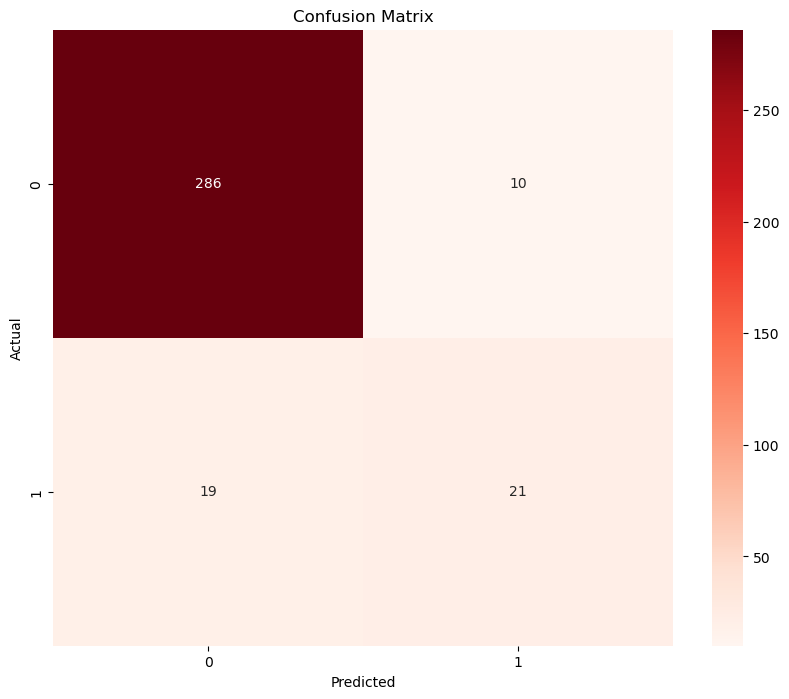

In [13]:
# Plot Confusion Matrix

y_pred = model.predict(feature.drop(columns=['EmployeeID']))

cm = confusion_matrix(labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

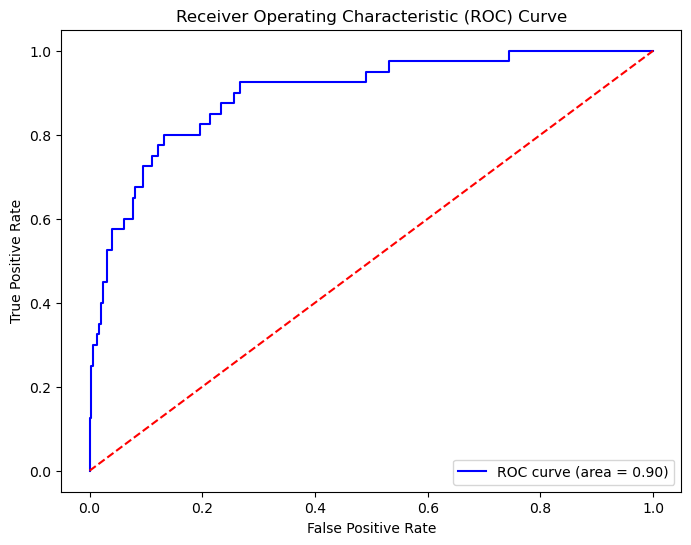

In [14]:
# ROC AUC Curve
y_prob = model.predict_proba(feature.drop(columns=['EmployeeID']))[:, 1]
fpr, tpr, thresholds = roc_curve(labels, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


In [15]:
# Classification Report
print(classification_report(labels, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       296
           1       0.68      0.53      0.59        40

    accuracy                           0.91       336
   macro avg       0.81      0.75      0.77       336
weighted avg       0.91      0.91      0.91       336



Component Testing

In [5]:
# Set Models with different random states
model1 = joblib.load('./models/xgb_model.joblib')
model2 = joblib.load('./models/xgb_model.joblib')
model3 = joblib.load('./models/xgb_model.joblib')

model1.set_params(random_state=42)
model2.set_params(random_state=45)
model3.set_params(random_state=48)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [7]:
# Get shap values for employee with ID 1628396

values1 = get_employee_shap_values(model1, 1780761, dataset)
values2 = get_employee_shap_values(model2, 1780761, dataset)
values3 = get_employee_shap_values(model3, 1780761, dataset)

In [8]:
print(values1)

{'Age': 0.06856289826400047, 'BusinessTravel': -0.0009907260483929066, 'DailyRate': 0.004333790821089813, 'DistanceFromHome': 0.06154691072081082, 'Education': 0.000840386663829642, 'EducationField': 0.0015244510272584314, 'EnvironmentSatisfaction': -0.01794964265469129, 'HourlyRate': 0.003599173501965456, 'JobInvolvement': -0.0393486295746074, 'JobLevel': -0.020025964642409237, 'JobRole': -0.006396749024113106, 'JobSatisfaction': -0.021101696893705852, 'MaritalStatus': -0.013174229076664367, 'MonthlyIncome': -0.00996628054683762, 'MonthlyRate': 0.015453062352275341, 'NumCompaniesWorked': -0.009071121596664717, 'OverTime': -0.11040924378670754, 'PercentSalaryHike': 0.014925842018565163, 'PerformanceRating': 0.0, 'RelationshipSatisfaction': 0.006680893147464046, 'Shift': -0.0481598181026389, 'TotalWorkingYears': -0.0005552066847615457, 'TrainingTimesLastYear': 0.006136002524622848, 'WorkLifeBalance': -0.024406981769882676, 'YearsAtCompany': -0.006864475353088766, 'YearsInCurrentRole': 0

In [9]:
print(values2)

{'Age': 0.07782393194735052, 'BusinessTravel': -0.0013547344219737851, 'DailyRate': 0.0027457067804477595, 'DistanceFromHome': 0.0752399813437036, 'Education': 0.0013503037265036263, 'EducationField': 0.0016844411385578298, 'EnvironmentSatisfaction': -0.014558280998441793, 'HourlyRate': 0.004489984471251117, 'JobInvolvement': -0.03311413806597036, 'JobLevel': -0.023226823960763535, 'JobRole': -0.005922646784123835, 'JobSatisfaction': -0.02080718806229664, 'MaritalStatus': -0.015705439818723663, 'MonthlyIncome': -0.015759318111065252, 'MonthlyRate': 0.014031698658945971, 'NumCompaniesWorked': -0.008719251225868767, 'OverTime': -0.13188769371947276, 'PercentSalaryHike': 0.016334741847988752, 'PerformanceRating': 0.0, 'RelationshipSatisfaction': 0.009207806041896605, 'Shift': -0.05294524906610603, 'TotalWorkingYears': 0.004559193249359458, 'TrainingTimesLastYear': 0.00572690546446081, 'WorkLifeBalance': -0.023967744770759185, 'YearsAtCompany': -0.0030006540578324326, 'YearsInCurrentRole':

In [10]:
print(values3)

{'Age': 0.0687334910935689, 'BusinessTravel': -0.0022878714915298454, 'DailyRate': 0.003602519588478446, 'DistanceFromHome': 0.059375975091908395, 'Education': 0.0009051987844785406, 'EducationField': 0.0016666765060342327, 'EnvironmentSatisfaction': -0.01614035172254911, 'HourlyRate': 0.00526808103064208, 'JobInvolvement': -0.03425389013319675, 'JobLevel': -0.026604012973007882, 'JobRole': -0.006616839967318805, 'JobSatisfaction': -0.0194860430944079, 'MaritalStatus': -0.013253396891523158, 'MonthlyIncome': -0.01176656416567441, 'MonthlyRate': 0.017025901581426816, 'NumCompaniesWorked': -0.011065694883332715, 'OverTime': -0.11150870776710299, 'PercentSalaryHike': 0.020233101156523586, 'PerformanceRating': 0.0, 'RelationshipSatisfaction': 0.008324407043567463, 'Shift': -0.057535511319625324, 'TotalWorkingYears': -0.0006239228617466472, 'TrainingTimesLastYear': 0.005154070515418424, 'WorkLifeBalance': -0.02986129282774138, 'YearsAtCompany': -0.005463416031894409, 'YearsInCurrentRole': 0

In [11]:
# Compare the SHAP values across the three models
shap_df = pd.DataFrame({
    'Feature': list(values1.keys()),
    'Model_1': list(values1.values()),
    'Model_2': list(values2.values()),
    'Model_3': list(values3.values())
})

shap_df.head()

,Feature,Model_1,Model_2,Model_3
0,Age,0.068563,0.077824,0.068733
1,BusinessTravel,-0.000991,-0.001355,-0.002288
2,DailyRate,0.004334,0.002746,0.003603
3,DistanceFromHome,0.061547,0.075240,0.059376
4,Education,0.000840,0.001350,0.000905
